# Amazon tipping-like abrupt shifts using CMIP6 model

**Computational Narrative**

This notebook documents the full analysis pipeline: preprocessing CMIP6 GFDL-ESM4
1pctCO2 experiment data over the Amazon basin, then using TOAD
(Threshold/Optimization/Anomaly Detection) to detect ecological shifts and spatial
clusters across several ecosystem variables.

**Pipeline at a glance**

```
config.json  --->  preprocess.py  --->  run_pipeline.py  --->  toad_runner.py  --->  results
(per-variable      (raw CMIP6           (orchestrates            (runs TOAD shift/     (.nc / .png / csv)
 settings)          -> .nc, .png)        model x variable)         cluster detection)
```

- **Input**: `config.json` -- centralizes the model name and each variable's preprocessing/plot/TOAD settings
- **Preprocessing**: `preprocess.py` -- raw CMIP6 `.nc` -> Amazon-masked, GWL (Global Warming Level) indexed -> `processed_data/*.nc`, `plots/*.png`
- **TOAD stage**: `toad_runner.py` -- takes the preprocessed `.nc` as input, runs shift detection (ASDETECT) + optimized clustering (SpaceTimeDBSCAN) -> `results_toad/{model}/{variable}/.../`
- **Orchestration**: `run_pipeline.py` -- iterates over `configs/*.json` and runs the two stages above automatically for every (model, variable) combination

This notebook loads outputs that were already produced by `run_pipeline.py` and
narrates the process; it does not re-run the heavy preprocessing/TOAD computation
itself. (See the Reproducibility Appendix at the end for how to re-run everything.)


## 1. Setup & Environment

Import the libraries needed for this notebook. `preprocess.py` / `toad_runner.py`
are imported directly so we can reuse the pipeline's own path-naming helpers
instead of re-hardcoding file paths (e.g. `TOAD_{variable}_{model}{suffix}.nc`)
here -- that way the notebook always follows exactly the same conventions as
the pipeline code.


In [11]:
import os
import sys
import json
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

# Add parent directory (Amazon/) to sys.path for importing preprocess and toad_runner
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

import preprocess
import toad_runner

# Set paths relative to Amazon/ directory (executed from docs/)
CONFIG_PATH = "../configs/config_GFDL-ESM4.json"  # or config_TaiESM1.json
PROCESSED_DIR = Path("../processed_data")
PLOTS_DIR = Path("../plots")
RESULTS_DIR = Path("../results_toad")

print("Python:", platform.python_version())
for pkg in [np, pd, xr]:
    print(f"{pkg.__name__}: {pkg.__version__}")

Python: 3.13.5
numpy: 2.4.6
pandas: 2.2.3
xarray: 2025.4.0


In [12]:
def show_image_if_exists(path, caption=None):
    '''Displays an image if it exists, otherwise prints a friendly notice.
    Keeps the notebook runnable even before the real pipeline has been executed.'''
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path)))
        if caption:
            display(Markdown(f"*{caption}*"))
    else:
        display(Markdown(f"> ⚠️ **File not found**: `{path}` -- run `run_pipeline.py` first."))


## 2. Data & Research Background

### Experimental design
- **Model**: GFDL-ESM4 (CMIP6)
- **Experiments**: `1pctCO2` (CO2 increasing 1%/year) vs. `piControl` (pre-industrial control run)
- **Spatial domain**: Amazon basin (masked with `amazon_sensulatissimo_gmm_v1.shp`, roughly lat -20~10, lon 280~320)
- **Time axis**: instead of calendar year, we use **GWL (Global Warming Level)**. The
  annual global-mean temperature of `1pctCO2` is expressed as an anomaly relative to
  the `piControl` baseline (following the Terpstra et al. approach, with sigma=10-year
  Gaussian smoothing), and that value becomes the time axis -- so every result is
  compared on a "at X °C of warming" basis rather than by calendar year.

### Variables analyzed

| Variable | Description | Preprocessing type |
|---|---|---|
| `cVeg` | Vegetation carbon (kgC/m²) | simple (mean) |
| `MCWD` | Max Cumulative Water Deficit (mm), computed over an Oct-Sep hydrological year | custom (pr - evspsbl formula) |
| `fFire` | Fire CO₂ emission flux | simple (sum, flux -> annual total) |
| `grassFrac` | Grass area fraction (%) | simple (mean) |
| `treeFrac` | Tree cover fraction (%) | simple (mean) |
| `AnnualRainfall` | Annual total rainfall (mm), derived from the `pr` variable | simple (sum, flux -> annual total) |

*(Fill in the research rationale for each variable choice here.)*


## 3. Pipeline Architecture

### Why it's split this way

| Component | Role | Key design decision |
|---|---|---|
| `config.json` | Per-variable `preprocessing`/`plot`/`toad` settings for one model | Externalizes all behavior to JSON so new variables/settings can be added without touching code |
| `preprocess.py` | raw CMIP6 -> Amazon mask -> GWL indexing -> `.nc` + plots | `type: simple` uses a single `SimpleProcessor` (parameterized by aggregation/unit_conversion); `type: custom` dispatches through a `formula_id` registry (`FORMULA_REGISTRY`) so new formulas can be added without touching the rest of the file |
| `run_pipeline.py` | Iterates over `configs/*.json` and runs preprocess -> TOAD for every (model, variable) combination | One failing combination doesn't stop the rest; prints a success/failure summary at the end |
| `toad_runner.py` | Runs TOAD shift/cluster detection on a preprocessed `.nc` | **The JSON is the single source of truth** -- the `.nc` file itself stores no TOAD settings; `toad_runner.py` re-reads the same `config.json` at run time. shift_method/cluster_method are resolved by name via registries (`SHIFT_METHOD_REGISTRY`/`CLUSTER_METHOD_REGISTRY`) |

### Why it was designed this way (summary of the design discussion)
- We considered **re-reading the JSON at each stage vs. embedding TOAD settings in the
  `.nc` file's attrs**, and chose **re-reading the JSON directly** because TOAD
  parameters (e.g. `optimize_params`) get re-tuned far more often than preprocessing
  settings do. This way, re-tuning them never requires regenerating the (expensive)
  `.nc` file.
- `preprocess.py`'s `SimpleProcessor` handles both `cVeg` (mean, no conversion) and
  `fFire`/`AnnualRainfall` (sum, flux -> annual total conversion) with the same class --
  this refactor also fixed a bug where `fFire` actually needed sum aggregation but was
  previously only ever averaged.


In [13]:
# Actually scan the file structure rather than describing it -- this reflects real state.
def print_tree(root, max_depth=3, _prefix="", _depth=0):
    root = Path(root)
    if not root.exists():
        print(f"(path not found: {root})")
        return
    if _depth > max_depth:
        return
    entries = sorted(root.iterdir(), key=lambda p: (p.is_file(), p.name)) if root.is_dir() else []
    for i, entry in enumerate(entries):
        connector = "└── " if i == len(entries) - 1 else "├── "
        print(f"{_prefix}{connector}{entry.name}")
        if entry.is_dir():
            extension = "    " if i == len(entries) - 1 else "│   "
            print_tree(entry, max_depth=max_depth, _prefix=_prefix + extension, _depth=_depth + 1)

print("./ (project root)")
print_tree(".", max_depth=2)


./ (project root)
├── TOAD_Amazon_main.ipynb
└── analysis_narrative.ipynb


## 4. Configuration

Rather than copying `config.json`'s contents by hand, we load the actual file **in
code** and render it as tables. These tables are exactly the settings that were
used for this run.


In [14]:
pipeline_json = preprocess.load_pipeline_json(CONFIG_PATH)
model_name = pipeline_json["model"]
print("Model:", model_name)

rows = []
for var, cfg in pipeline_json["variable_settings"].items():
    prep = cfg.get("preprocessing", {})
    rows.append({
        "variable": var,
        "type": prep.get("type"),
        "aggregation": prep.get("aggregation"),
        "unit_conversion": prep.get("unit_conversion"),
        "time_frequency": prep.get("time_frequency"),
        "rolling_years": prep.get("rolling_years"),
        "formula_id": prep.get("formula_id"),
        "inputs": prep.get("inputs"),
    })

preprocessing_df = pd.DataFrame(rows).set_index("variable")
preprocessing_df


Model: GFDL-ESM4


,type,aggregation,unit_conversion,time_frequency,rolling_years,formula_id,inputs
variable,,,,,,,
cVeg,simple,mean,none,1YS,1,None,None
MCWD,custom,None,flux_to_monthly_mm,1YS,10,MCWD_hydrological_year,"[pr, evspsbl]"
fFire,simple,sum,flux_to_annual_total,1YS,10,None,None
grassFrac,simple,mean,none,1YS,1,None,None
treeFrac,simple,mean,none,1YS,1,None,None
AnnualRainfall,simple,sum,flux_to_annual_total,1YS,10,None,None


In [ ]:
toad_rows = []
for var, cfg in pipeline_json["variable_settings"].items():
    toad_cfg = cfg.get("toad", {})
    shift_cfg = toad_cfg.get("shift", {})
    cluster_cfg = toad_cfg.get("cluster", {})
    
    optimize_params = cluster_cfg.get("optimize_params", {})
    toad_rows.append({
        "variable": var,
        "shift_method": shift_cfg.get("shift_method"),
        "cluster_method": cluster_cfg.get("cluster_method"),
        "shift_direction": shift_cfg.get("shift_direction"),
        "shift_selection": shift_cfg.get("shift_selection"),
        "optimize_objective": cluster_cfg.get("optimize_objective"),
        "optimize_n_trials": cluster_cfg.get("optimize_n_trials"),
        "spatial_eps": str(optimize_params.get("spatial_eps")) if optimize_params.get("spatial_eps") else None,
        "temporal_eps": str(optimize_params.get("temporal_eps")) if optimize_params.get("temporal_eps") else None,
        "min_samples": str(optimize_params.get("min_samples")) if optimize_params.get("min_samples") else None,
    })

toad_config_df = pd.DataFrame(toad_rows).set_index("variable")
toad_config_df

**Observation**: apart from `shift_direction`, almost every TOAD setting
(shift_method, cluster_method, shift_selection, optimize_objective, optimize_params,
optimize_n_trials) is identical across all six variables. Only `fFire`/`grassFrac`
use `positive` (detecting increasing shifts); the rest use `negative` (decreasing
shifts) -- e.g. fire emissions and grass cover are expected to *increase* under
warming, while cVeg/MCWD/treeFrac/AnnualRainfall are expected to show *decreasing*
shifts.


## 5. Preprocessing Methodology

### 5.1 `simple` type (`SimpleProcessor`)
The raw CMIP6 variable is clipped to the Amazon basin, then, per config:

1. **unit_conversion**: `none` leaves values as-is; `flux_to_annual_total` multiplies
   each monthly per-second flux by that month's number of seconds
   (`days_in_month * 86400`) to get a monthly total
2. **aggregation**: resample to `time_frequency` (default `1YS`) using either
   `mean` (annual mean) or `sum` (annual total)

`cVeg`/`grassFrac`/`treeFrac` use the (mean, none) combination; `fFire`/`AnnualRainfall`
use (sum, flux_to_annual_total) -- the same class is reused with different parameters.

### 5.2 `custom` type (MCWD, `formula_id: MCWD_hydrological_year`)

$$
\text{CWD}_i = \min(0,\ \text{CWD}_{i-1} + P_i - E_i), \qquad
\text{MCWD} = \min_i(\text{CWD}_i)
$$

- $P_i$, $E_i$: monthly precipitation and evapotranspiration (converted from kg m⁻² s⁻¹ to mm/month)
- October through the following September is treated as one "hydrological year"
  (reflecting the tropical/southern-hemisphere wet season pattern)
- Because the formula is looked up from `FORMULA_REGISTRY` via `formula_id`, adding a
  new custom variable only requires registering one new function -- no other part
  of `preprocess.py` needs to change.

### 5.3 GWL (Global Warming Level) calculation
1. Compute the area-weighted global mean of `tas` (temperature) as an annual mean, for both `1pctCO2` and `piControl`
2. Use the full-period mean of `piControl` as the pre-industrial baseline
3. Apply 10-year sigma Gaussian smoothing to the `1pctCO2` annual-mean temperature, then subtract the baseline to get GWL
4. Use this GWL value as the time axis (coordinate) of the final `.nc` file -- so every
   result can be compared by "degrees of warming" rather than by calendar year.


## 6. Preprocessing Results

### 6.0 Model year vs. GWL

This GWL calculation is shared across all six variables (generated once per model,
independent of variable).


In [ ]:
show_image_if_exists(
    PLOTS_DIR / model_name / f"GWL_ModelYear_{model_name}.png",
    caption=f"GWL trend by 1pctCO2 model year for {model_name}",
)

### 6.1 Representative variable in detail: `cVeg` (`simple` type example)


In [17]:
def variable_paths(model, variable, config_path=CONFIG_PATH):
    '''Reuses preprocess.py/toad_runner.py's own naming conventions to compute
    the actual output paths (no hardcoding).'''
    pj = preprocess.load_pipeline_json(config_path)
    var_cfg = preprocess.get_variable_config(pj, variable)
    rolling_years = var_cfg.get("preprocessing", {}).get("rolling_years")
    suffix = preprocess.smoothing_suffix(rolling_years)

    nc_path = PROCESSED_DIR / f"TOAD_{variable}_{model}{suffix}.nc"
    trend_png = PLOTS_DIR / f"TrendPlot_{variable}_{model}{suffix}.png"
    spatial_png = PLOTS_DIR / f"SpatialMap_{variable}_{model}{suffix}.png"

    return {
        "rolling_years": rolling_years,
        "nc_path": nc_path,
        "trend_png": trend_png,
        "spatial_png": spatial_png,
    }

cveg_paths = variable_paths(model_name, "cVeg")
print(cveg_paths)


{'rolling_years': 1, 'nc_path': PosixPath('../processed_data/TOAD_cVeg_GFDL-ESM4.nc'), 'trend_png': PosixPath('../plots/TrendPlot_cVeg_GFDL-ESM4.png'), 'spatial_png': PosixPath('../plots/SpatialMap_cVeg_GFDL-ESM4.png')}


In [18]:
if cveg_paths["nc_path"].exists():
    ds = xr.open_dataset(cveg_paths["nc_path"])
    display(ds)
else:
    display(Markdown(f"> ⚠️ **File not found**: `{cveg_paths['nc_path']}` -- run `run_pipeline.py` first."))


> ⚠️ **File not found**: `../processed_data/TOAD_cVeg_GFDL-ESM4.nc` -- run `run_pipeline.py` first.

In [19]:
show_image_if_exists(cveg_paths["trend_png"], caption="cVeg: Amazon basin mean vs. GWL")
show_image_if_exists(cveg_paths["spatial_png"], caption="cVeg: spatial distribution across GWL bins")


> ⚠️ **File not found**: `../plots/TrendPlot_cVeg_GFDL-ESM4.png` -- run `run_pipeline.py` first.

> ⚠️ **File not found**: `../plots/SpatialMap_cVeg_GFDL-ESM4.png` -- run `run_pipeline.py` first.

### 6.2 Representative variable in detail: `MCWD` (`custom` type example, with a 10-year rolling mean)


In [20]:
mcwd_paths = variable_paths(model_name, "MCWD")
print(mcwd_paths)

if mcwd_paths["nc_path"].exists():
    ds = xr.open_dataset(mcwd_paths["nc_path"])
    display(ds)
else:
    display(Markdown(f"> ⚠️ **File not found**: `{mcwd_paths['nc_path']}` -- run `run_pipeline.py` first."))


{'rolling_years': 10, 'nc_path': PosixPath('../processed_data/TOAD_MCWD_GFDL-ESM4_smooth10yr.nc'), 'trend_png': PosixPath('../plots/TrendPlot_MCWD_GFDL-ESM4_smooth10yr.png'), 'spatial_png': PosixPath('../plots/SpatialMap_MCWD_GFDL-ESM4_smooth10yr.png')}


> ⚠️ **File not found**: `../processed_data/TOAD_MCWD_GFDL-ESM4_smooth10yr.nc` -- run `run_pipeline.py` first.

In [21]:
show_image_if_exists(mcwd_paths["trend_png"], caption="MCWD: Amazon basin mean vs. GWL (10-year rolling mean)")
show_image_if_exists(mcwd_paths["spatial_png"], caption="MCWD: spatial distribution across GWL bins")


> ⚠️ **File not found**: `../plots/TrendPlot_MCWD_GFDL-ESM4_smooth10yr.png` -- run `run_pipeline.py` first.

> ⚠️ **File not found**: `../plots/SpatialMap_MCWD_GFDL-ESM4_smooth10yr.png` -- run `run_pipeline.py` first.

### 6.3 Remaining variables, summarized (`fFire`, `grassFrac`, `treeFrac`, `AnnualRainfall`)

Instead of repeating the full walkthrough, we compress these into summary
statistics and a grid of trend plot thumbnails.


In [22]:
summary_variables = ["fFire", "grassFrac", "treeFrac", "AnnualRainfall"]
summary_rows = []

for var in summary_variables:
    paths = variable_paths(model_name, var)
    if paths["nc_path"].exists():
        ds = xr.open_dataset(paths["nc_path"])
        da = ds[var]
        summary_rows.append({
            "variable": var,
            "rolling_years": paths["rolling_years"],
            "n_GWL_steps": da.sizes.get("GWL", 0),
            "min": float(da.min(skipna=True)),
            "mean": float(da.mean(skipna=True)),
            "max": float(da.max(skipna=True)),
        })
    else:
        summary_rows.append({
            "variable": var,
            "rolling_years": paths["rolling_years"],
            "n_GWL_steps": None,
            "min": None, "mean": None, "max": None,
        })

summary_df = pd.DataFrame(summary_rows).set_index("variable")
summary_df


,rolling_years,n_GWL_steps,min,mean,max
variable,,,,,
fFire,10,None,None,None,None
grassFrac,1,None,None,None,None
treeFrac,1,None,None,None,None
AnnualRainfall,10,None,None,None,None


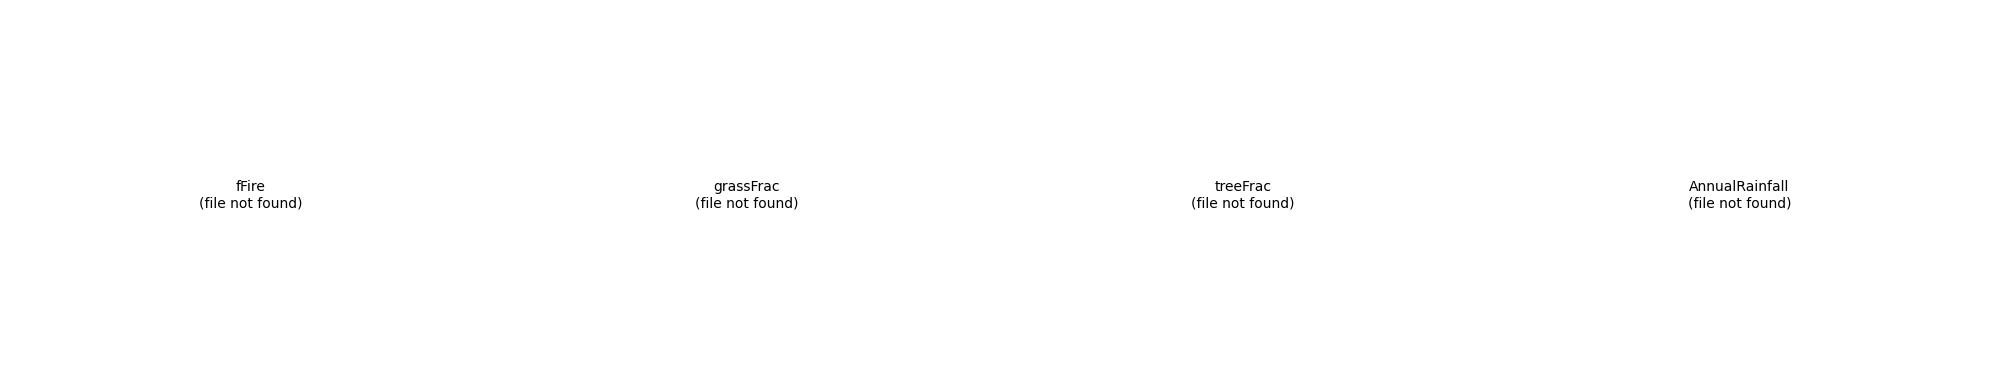

In [23]:
fig, axes = plt.subplots(1, len(summary_variables), figsize=(5 * len(summary_variables), 4))
for ax, var in zip(axes, summary_variables):
    paths = variable_paths(model_name, var)
    if paths["trend_png"].exists():
        ax.imshow(plt.imread(paths["trend_png"]))
        ax.axis("off")
        ax.set_title(var)
    else:
        ax.text(0.5, 0.5, f"{var}\n(file not found)", ha="center", va="center")
        ax.axis("off")
plt.tight_layout()
plt.show()


## 7. TOAD Stage

### 7.1 Shift Detection -- `ASDETECT`
For each grid cell's time series, detects abrupt changes (shifts) as a function of
GWL. The algorithm is specified via `config.json`'s `toad.shift.shift_method`,
resolved from name to class by `toad_runner.py`'s `SHIFT_METHOD_REGISTRY`, and
passed to `td.compute_shifts(method=...)`.

### 7.2 Clustering -- `SpaceTimeDBSCAN` (+ Optuna-based parameter optimization)
Detected shifts are clustered by spatial (`spatial_eps`) and temporal (`temporal_eps`)
proximity. The search explores the ranges given in `optimize_params`
(`spatial_eps`, `temporal_eps`, `min_samples`) over `optimize_n_trials` trials,
maximizing `optimize_objective` (default `mean_spatial_autocorrelation`).

### 7.3 Settings actually used


In [24]:
toad_config_df

,shift_method,cluster_method,shift_direction,shift_selection,optimize_objective,optimize_n_trials,spatial_eps,temporal_eps,min_samples
variable,,,,,,,,,
cVeg,FilteredASDETECT,None,negative,local,None,None,None,None,None
MCWD,ASDETECT,None,negative,local,None,None,None,None,None
fFire,ASDETECT,SpaceTimeDBSCAN,positive,local,None,None,None,None,None
grassFrac,FilteredASDETECT,SpaceTimeDBSCAN,positive,local,None,None,None,None,None
treeFrac,FilteredASDETECT,None,negative,local,None,None,None,None,None
AnnualRainfall,ASDETECT,None,negative,local,None,None,None,None,None


## 8. TOAD Results

We reconstruct the results directory path using the same naming convention as
`toad_runner.make_run_dir()`, then load `metadata.json` / `cluster_stats.csv` /
the diagnostic plots.


In [25]:
def toad_result_dir(model, variable, config_path=CONFIG_PATH):
    '''Reconstructs the TOAD results directory that run_pipeline.py actually wrote to.'''
    paths = variable_paths(model, variable, config_path)
    run_config = toad_runner.build_run_config_from_json(
        config_path, model, variable, paths["rolling_years"]
    )
    run_dir_path = toad_runner.RESULTS_DIR / (
        f"{run_config['model']}/"
        f"{run_config['variable']}/"
        f"{toad_runner.smoothing_label(run_config['rolling_years'])}/"
        f"{run_config['method']}_"
        f"{toad_runner.optimize_range_label(run_config['optimize_params'])}_"
        f"{run_config['optimize_objective']}_"
        f"n{run_config['optimize_n_trials']}_"
        f"{run_config['shift_direction']}_"
        f"{run_config['shift_selection']}"
    )
    return run_dir_path

cveg_run_dir = toad_result_dir(model_name, "cVeg")
print(cveg_run_dir)


/Users/kim-wonjin/Documents/CLEWS/Python/TOAD_CLEWS/Amazon/results_toad/GFDL-ESM4/cVeg/annual/SpaceTimeDBSCAN_sp300-1000_t0p2-0p8_ms9-50_mean_spatial_autocorrelation_n1000_negative_local


In [26]:
def show_toad_run(run_dir):
    run_dir = Path(run_dir)
    meta_path = run_dir / "metadata.json"
    stats_path = run_dir / "cluster_stats.csv"

    if meta_path.exists():
        with open(meta_path) as f:
            meta = json.load(f)
        display(Markdown(
            f"**n_clusters**: {meta.get('n_clusters')}  |  "
            f"**best_score**: {meta.get('best_score')}  |  "
            f"**best_spatial_eps**: {meta.get('best_spatial_eps')}  |  "
            f"**best_temporal_eps**: {meta.get('best_temporal_eps')}  |  "
            f"**best_min_samples**: {meta.get('best_min_samples')}"
        ))
    else:
        display(Markdown(f"> ⚠️ **File not found**: `{meta_path}`"))

    if stats_path.exists():
        display(pd.read_csv(stats_path).head(10))
    else:
        display(Markdown(f"> ⚠️ **File not found**: `{stats_path}`"))

    plot_dir = run_dir / "plots"
    for png_name, caption in [
        ("01_max_shift_map.png", "Maximum shift magnitude map"),
        ("02_time_of_max_shift_map.png", "Time (GWL) of maximum shift map"),
        ("03_timeseries.png", "Per-cluster time series"),
        ("04_overview_global.png", "Overview (global projection)"),
        ("05_overview_aggregated.png", "Overview (aggregated)"),
    ]:
        show_image_if_exists(plot_dir / png_name, caption=caption)

show_toad_run(cveg_run_dir)


> ⚠️ **File not found**: `/Users/kim-wonjin/Documents/CLEWS/Python/TOAD_CLEWS/Amazon/results_toad/GFDL-ESM4/cVeg/annual/SpaceTimeDBSCAN_sp300-1000_t0p2-0p8_ms9-50_mean_spatial_autocorrelation_n1000_negative_local/metadata.json`

> ⚠️ **File not found**: `/Users/kim-wonjin/Documents/CLEWS/Python/TOAD_CLEWS/Amazon/results_toad/GFDL-ESM4/cVeg/annual/SpaceTimeDBSCAN_sp300-1000_t0p2-0p8_ms9-50_mean_spatial_autocorrelation_n1000_negative_local/cluster_stats.csv`

> ⚠️ **File not found**: `/Users/kim-wonjin/Documents/CLEWS/Python/TOAD_CLEWS/Amazon/results_toad/GFDL-ESM4/cVeg/annual/SpaceTimeDBSCAN_sp300-1000_t0p2-0p8_ms9-50_mean_spatial_autocorrelation_n1000_negative_local/plots/01_max_shift_map.png` -- run `run_pipeline.py` first.

> ⚠️ **File not found**: `/Users/kim-wonjin/Documents/CLEWS/Python/TOAD_CLEWS/Amazon/results_toad/GFDL-ESM4/cVeg/annual/SpaceTimeDBSCAN_sp300-1000_t0p2-0p8_ms9-50_mean_spatial_autocorrelation_n1000_negative_local/plots/02_time_of_max_shift_map.png` -- run `run_pipeline.py` first.

> ⚠️ **File not found**: `/Users/kim-wonjin/Documents/CLEWS/Python/TOAD_CLEWS/Amazon/results_toad/GFDL-ESM4/cVeg/annual/SpaceTimeDBSCAN_sp300-1000_t0p2-0p8_ms9-50_mean_spatial_autocorrelation_n1000_negative_local/plots/03_timeseries.png` -- run `run_pipeline.py` first.

> ⚠️ **File not found**: `/Users/kim-wonjin/Documents/CLEWS/Python/TOAD_CLEWS/Amazon/results_toad/GFDL-ESM4/cVeg/annual/SpaceTimeDBSCAN_sp300-1000_t0p2-0p8_ms9-50_mean_spatial_autocorrelation_n1000_negative_local/plots/04_overview_global.png` -- run `run_pipeline.py` first.

> ⚠️ **File not found**: `/Users/kim-wonjin/Documents/CLEWS/Python/TOAD_CLEWS/Amazon/results_toad/GFDL-ESM4/cVeg/annual/SpaceTimeDBSCAN_sp300-1000_t0p2-0p8_ms9-50_mean_spatial_autocorrelation_n1000_negative_local/plots/05_overview_aggregated.png` -- run `run_pipeline.py` first.

### 8.1 Representative variable in detail: `MCWD` TOAD results


In [27]:
mcwd_run_dir = toad_result_dir(model_name, "MCWD")
show_toad_run(mcwd_run_dir)


> ⚠️ **File not found**: `/Users/kim-wonjin/Documents/CLEWS/Python/TOAD_CLEWS/Amazon/results_toad/GFDL-ESM4/MCWD/smooth10yr/SpaceTimeDBSCAN_sp300-1000_t0p2-0p8_ms9-50_mean_spatial_autocorrelation_n1000_negative_local/metadata.json`

> ⚠️ **File not found**: `/Users/kim-wonjin/Documents/CLEWS/Python/TOAD_CLEWS/Amazon/results_toad/GFDL-ESM4/MCWD/smooth10yr/SpaceTimeDBSCAN_sp300-1000_t0p2-0p8_ms9-50_mean_spatial_autocorrelation_n1000_negative_local/cluster_stats.csv`

> ⚠️ **File not found**: `/Users/kim-wonjin/Documents/CLEWS/Python/TOAD_CLEWS/Amazon/results_toad/GFDL-ESM4/MCWD/smooth10yr/SpaceTimeDBSCAN_sp300-1000_t0p2-0p8_ms9-50_mean_spatial_autocorrelation_n1000_negative_local/plots/01_max_shift_map.png` -- run `run_pipeline.py` first.

> ⚠️ **File not found**: `/Users/kim-wonjin/Documents/CLEWS/Python/TOAD_CLEWS/Amazon/results_toad/GFDL-ESM4/MCWD/smooth10yr/SpaceTimeDBSCAN_sp300-1000_t0p2-0p8_ms9-50_mean_spatial_autocorrelation_n1000_negative_local/plots/02_time_of_max_shift_map.png` -- run `run_pipeline.py` first.

> ⚠️ **File not found**: `/Users/kim-wonjin/Documents/CLEWS/Python/TOAD_CLEWS/Amazon/results_toad/GFDL-ESM4/MCWD/smooth10yr/SpaceTimeDBSCAN_sp300-1000_t0p2-0p8_ms9-50_mean_spatial_autocorrelation_n1000_negative_local/plots/03_timeseries.png` -- run `run_pipeline.py` first.

> ⚠️ **File not found**: `/Users/kim-wonjin/Documents/CLEWS/Python/TOAD_CLEWS/Amazon/results_toad/GFDL-ESM4/MCWD/smooth10yr/SpaceTimeDBSCAN_sp300-1000_t0p2-0p8_ms9-50_mean_spatial_autocorrelation_n1000_negative_local/plots/04_overview_global.png` -- run `run_pipeline.py` first.

> ⚠️ **File not found**: `/Users/kim-wonjin/Documents/CLEWS/Python/TOAD_CLEWS/Amazon/results_toad/GFDL-ESM4/MCWD/smooth10yr/SpaceTimeDBSCAN_sp300-1000_t0p2-0p8_ms9-50_mean_spatial_autocorrelation_n1000_negative_local/plots/05_overview_aggregated.png` -- run `run_pipeline.py` first.

### 8.2 Cross-variable comparison summary

Collects just the `metadata.json` for each variable to compare all six TOAD runs
at once.


In [28]:
comparison_rows = []
for var in pipeline_json["variable_settings"]:
    run_dir = toad_result_dir(model_name, var)
    meta_path = run_dir / "metadata.json"
    if meta_path.exists():
        with open(meta_path) as f:
            meta = json.load(f)
        comparison_rows.append({
            "variable": var,
            "shift_direction": meta.get("shift_direction"),
            "n_clusters": meta.get("n_clusters"),
            "best_score": meta.get("best_score"),
            "best_spatial_eps": meta.get("best_spatial_eps"),
            "best_temporal_eps": meta.get("best_temporal_eps"),
            "best_min_samples": meta.get("best_min_samples"),
        })
    else:
        comparison_rows.append({
            "variable": var, "shift_direction": None, "n_clusters": None,
            "best_score": None, "best_spatial_eps": None,
            "best_temporal_eps": None, "best_min_samples": None,
        })

comparison_df = pd.DataFrame(comparison_rows).set_index("variable")
comparison_df


,shift_direction,n_clusters,best_score,best_spatial_eps,best_temporal_eps,best_min_samples
variable,,,,,,
cVeg,None,None,None,None,None,None
MCWD,None,None,None,None,None,None
fFire,None,None,None,None,None,None
grassFrac,None,None,None,None,None,None
treeFrac,None,None,None,None,None,None
AnnualRainfall,None,None,None,None,None,None


## 9. Synthesis & Discussion

*(This section is a space for interpretation once you've reviewed the actual
results. Below is a scaffold of the questions worth answering here.)*

- Which variable showed the most/most distinct clusters? Is that ecologically plausible?
- Do the variables with `shift_direction: positive` (`fFire`/`grassFrac`) and those
  with `negative` (the rest) tell a consistent story (e.g. warming -> increasing
  fire/grass, decreasing tree cover/vegetation carbon/rainfall)?
- Do MCWD's (water stress) shift timings precede or follow cVeg's/treeFrac's shift timings?
- Are `best_spatial_eps`/`best_temporal_eps` landing at the edge of the searched
  range? (If so, the `optimize_params` ranges in `config.json` may need widening
  and re-running.)


## 10. Reproducibility Appendix

### How to re-run everything
```bash
python run_pipeline.py
```
This iterates over every model config JSON in `configs/*.json` and automatically
runs preprocessing + TOAD for every variable defined in that file's
`variable_settings`. To add a new model or variable, add a JSON to `configs/` or
add an entry to an existing JSON's `variable_settings` -- `run_pipeline.py` /
`preprocess.py` / `toad_runner.py` themselves don't need to change.

### Known schema gaps / notes
- `optimize_direction` (e.g. `"maximize"`) is not yet part of the `config.json`
  schema, so `toad_runner.py` falls back to its module-level default
  (`DEFAULT_OPTIMIZE_DIRECTION`).
- Derived variables whose name doesn't match a raw CMIP6 variable (like
  `AnnualRainfall`) are handled via `preprocess.py`'s `DERIVED_SOURCE_VARIABLES`
  mapping (`AnnualRainfall` -> `pr`). Adding a `"source_variable"` key to the JSON
  would make this work without that mapping table.
- All six variables currently share identical TOAD settings (`shift_method`,
  `cluster_method`, `shift_selection`, `optimize_objective`, `optimize_params`,
  `optimize_n_trials`) except for `shift_direction`. Reducing this duplication
  would mean restructuring the schema with a top-level `toad_defaults` block plus
  per-variable overrides (not yet applied).


In [29]:
print("Environment summary")
print("-" * 40)
print("Python:", platform.python_version())
print("Model:", model_name)
print("Config path:", CONFIG_PATH)
print("Variables:", list(pipeline_json["variable_settings"].keys()))


Environment summary
----------------------------------------
Python: 3.13.5
Model: GFDL-ESM4
Config path: ../configs/config_GFDL-ESM4.json
Variables: ['cVeg', 'MCWD', 'fFire', 'grassFrac', 'treeFrac', 'AnnualRainfall']
